In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import logging

# 로깅 설정
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")


In [2]:
def load_params(root, simcode):
    """
    Load CAMELS parameter file.

    Parameters
    ----------
    root : str
        Root directory where CAMELS data is stored.
    simcode : str
        Simulation code ("IllustrisTNG" or "SIMBA").

    Returns
    -------
    dict
        Dictionary containing arrays of Omega_m, sigma_8, SN1, AGN1, SN2, AGN2.
    """
    param_file = os.path.join(root, f"params_LH_{simcode}.txt")
    Omega_m, sigma_8, SN1, AGN1, SN2, AGN2 = np.loadtxt(param_file, unpack=True)
    return {
        "Omega_m": Omega_m,
        "sigma_8": sigma_8,
        "SN1": SN1,
        "AGN1": AGN1,
        "SN2": SN2,
        "AGN2": AGN2,
    }

def load_maps(root, field, simcode, z_tag="z=0.00"):
    """
    Load CAMELS map data file.

    Parameters
    ----------
    root : str
        Root directory where CAMELS data is stored.
    field : str
        Field type ("Mtot" or "P").
    simcode : str
        Simulation code ("IllustrisTNG" or "SIMBA").
    z_tag : str
        Redshift tag in filename.

    Returns
    -------
    np.ndarray
        Array of shape (1000, 15, 256, 256).
    """
    maps_file = os.path.join(root, f"Maps_{field}_{simcode}_LH_{z_tag}.npy")
    arr = np.load(maps_file)
    arr = arr.reshape(1000, 15, 256, 256)
    logging.info(f"Loaded {maps_file} with shape {arr.shape}")
    return arr


In [3]:
# 데이터 경로
ROOT = "./data/CAMELS_multifield"

# SIMBA 데이터 불러오기
params_simba = load_params(ROOT, "SIMBA")
maps_simba_mtot = load_maps(ROOT, "Mtot", "SIMBA")
maps_simba_p = load_maps(ROOT, "P", "SIMBA")

# 간단한 통계 출력
logging.info(f"SIMBA-Mtot mean={maps_simba_mtot.mean():.3e}, std={maps_simba_mtot.std():.3e}")
logging.info(f"SIMBA-P mean={maps_simba_p.mean():.3e}, std={maps_simba_p.std():.3e}")


2025-08-19 10:01:35,849 [INFO] Loaded ./data/CAMELS_multifield/Maps_Mtot_SIMBA_LH_z=0.00.npy with shape (1000, 15, 256, 256)
2025-08-19 10:01:37,191 [INFO] Loaded ./data/CAMELS_multifield/Maps_P_SIMBA_LH_z=0.00.npy with shape (1000, 15, 256, 256)
2025-08-19 10:01:39,884 [INFO] SIMBA-Mtot mean=4.163e+11, std=3.636e+12
2025-08-19 10:01:42,575 [INFO] SIMBA-P mean=5.314e+07, std=4.029e+09


In [4]:
import pandas as pd

# params_simba 딕셔너리를 DataFrame으로 변환
df = pd.DataFrame({k: v for k, v in params_simba.items()})

# 요약 통계 (개수, 평균, 최소, 최대)
summary = df.describe().loc[["count", "mean", "min", "max"]]
summary_T = summary.round(5)  # 전치 & 소수점 3자리
print(summary_T)


         Omega_m    sigma_8         SN1        AGN1         SN2        AGN2
count  1000.0000  1000.0000  1000.00000  1000.00000  1000.00000  1000.00000
mean      0.3000     0.8000     1.35253     1.35253     1.08202     1.08202
min       0.1002     0.6002     0.25035     0.25035     0.50035     0.50035
max       0.4998     0.9998     3.99446     3.99446     1.99861     1.99861


In [5]:
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt

def show_sample_grid(arr, sample_index=0, title="", box_size=25.0):
    """
    Visualize all 15 channels of a single sample in a grid using log scale,
    with physical scale (Mpc/h) shown on axes.

    Parameters
    ----------
    arr : np.ndarray
        Array of shape (N, 15, H, W).
    sample_index : int
        Which sample to visualize (default=0).
    title : str
        Figure title.
    box_size : float
        Physical size of the simulation box (default=25 Mpc/h).
    """
    fig, axes = plt.subplots(3, 5, figsize=(12, 7))
    sample = arr[sample_index]

    # vmin/vmax를 robust하게 설정 (outlier 영향 줄임)
    vmin = np.percentile(sample[sample > 0], 1)  # 양수 픽셀 하위 1%
    vmax = np.percentile(sample, 99)             # 상위 1%

    H, W = sample.shape[1:]  # 이미지 해상도 (보통 256 x 256)

    for i, ax in enumerate(axes.flat):
        img = sample[i]
        img = np.where(img > 0, img, vmin)  # log 스케일에서 0 보정
        im = ax.imshow(
            img,
            origin="lower",
            cmap="viridis",
            norm=LogNorm(vmin=vmin, vmax=vmax),
            extent=[0, box_size, 0, box_size]  # 물리적 길이 표시
        )
        ax.set_title(f"Ch {i}", fontsize=8)
        ax.set_xlabel("Mpc/h")
        ax.set_ylabel("Mpc/h")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


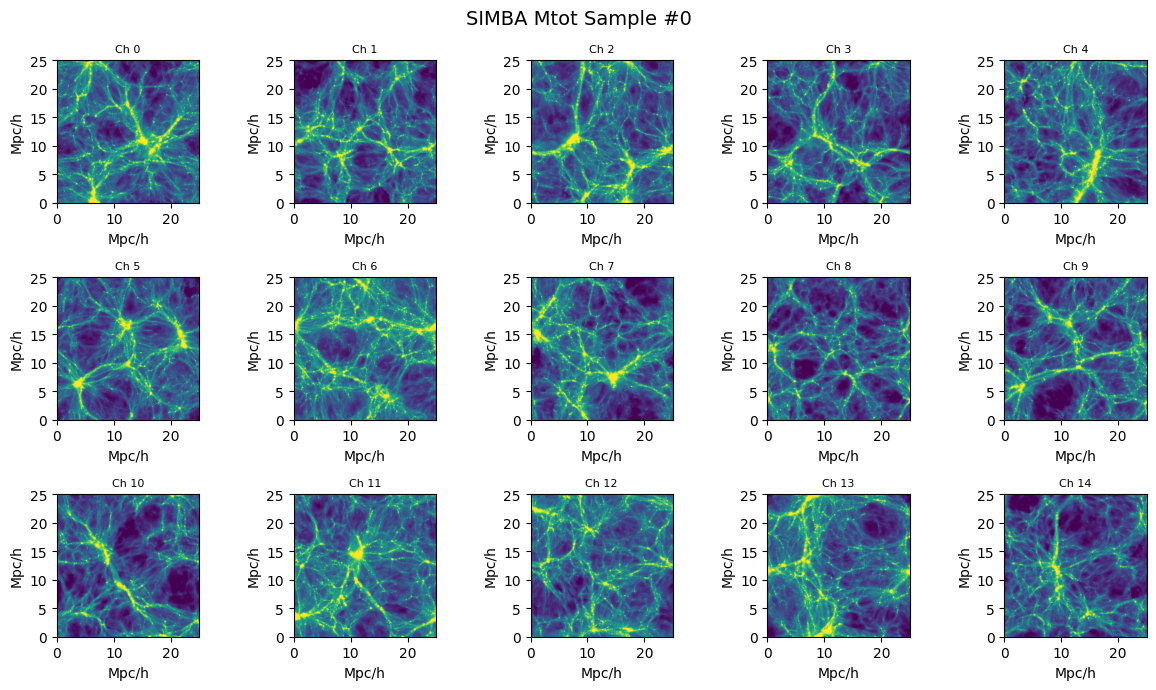

In [6]:
# SIMBA Mtot 샘플 시각화
show_sample_grid(maps_simba_mtot, sample_index=0, title="SIMBA Mtot Sample #0")


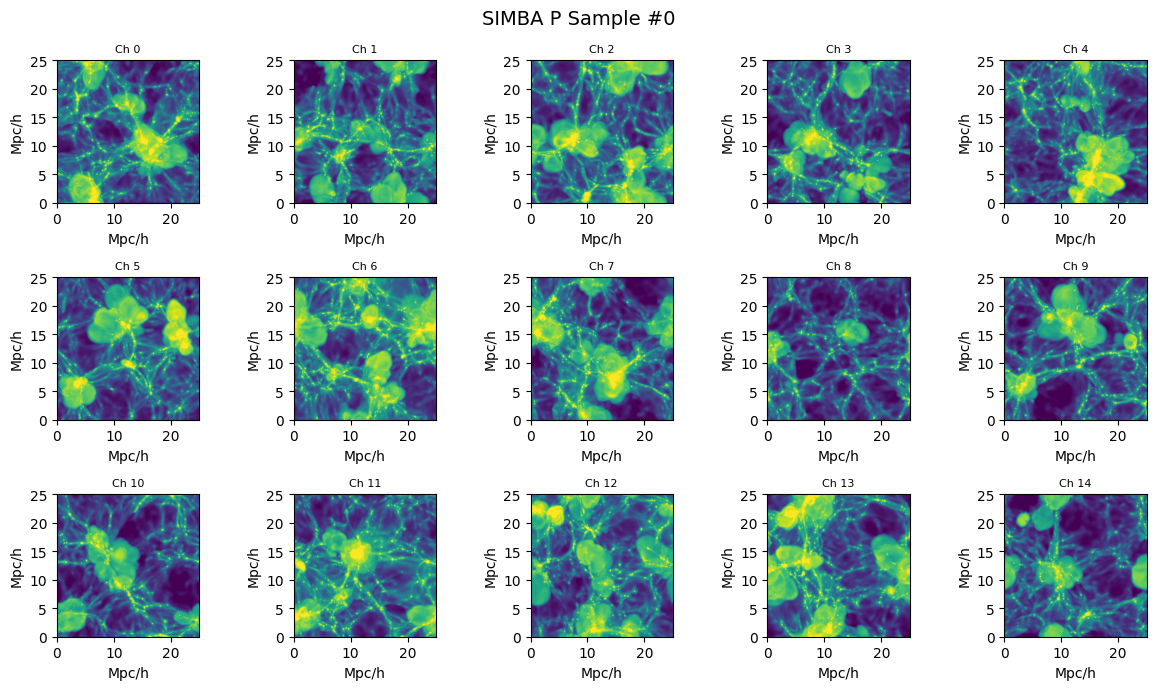

In [7]:
# SIMBA P 샘플 시각화
show_sample_grid(maps_simba_p, sample_index=0, title="SIMBA P Sample #0")

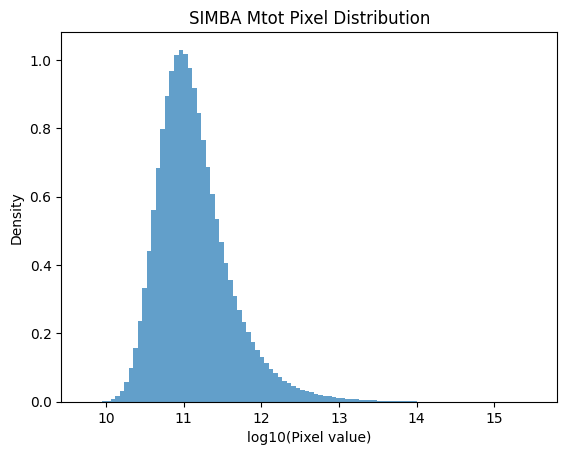

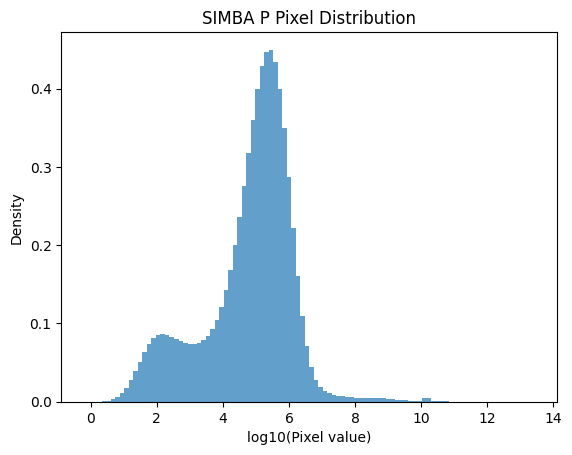

In [8]:
def plot_histograms(arr, title=""):
    """
    Plot histogram of pixel intensities with log scale for better visibility.
    """
    x = arr.reshape(-1)
    x = x[np.isfinite(x) & (x > 0)]  # log 스케일 위해 양수만

    plt.hist(np.log10(x), bins=100, density=True, alpha=0.7)
    plt.xlabel("log10(Pixel value)")
    plt.ylabel("Density")
    plt.title(title)
    plt.show()

# 전체 분포 확인
plot_histograms(maps_simba_mtot, title="SIMBA Mtot Pixel Distribution")
plot_histograms(maps_simba_p, title="SIMBA P Pixel Distribution")


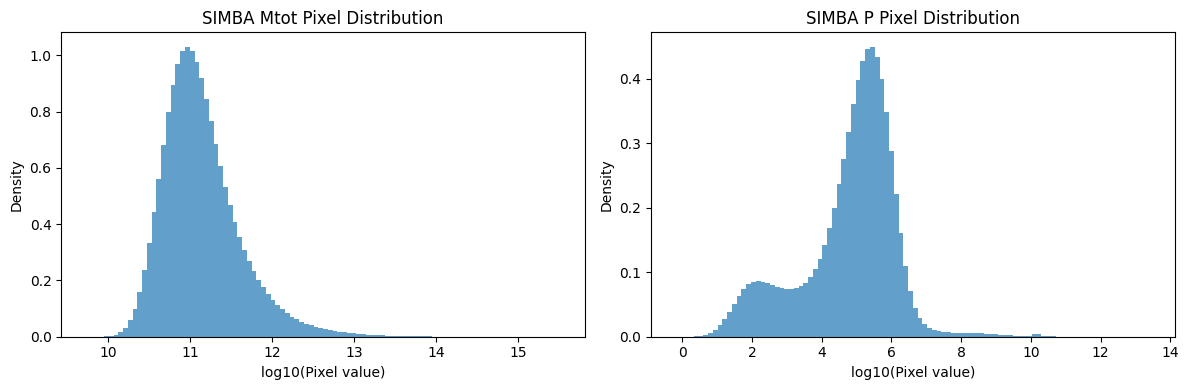

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_histograms_side_by_side(arr1, arr2, title1="", title2=""):
    """
    Plot two histograms side by side in one row.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1행 2열

    # 첫 번째 분포
    x1 = arr1.reshape(-1)
    x1 = x1[np.isfinite(x1) & (x1 > 0)]
    axes[0].hist(np.log10(x1), bins=100, density=True, alpha=0.7)
    axes[0].set_xlabel("log10(Pixel value)")
    axes[0].set_ylabel("Density")
    axes[0].set_title(title1)

    # 두 번째 분포
    x2 = arr2.reshape(-1)
    x2 = x2[np.isfinite(x2) & (x2 > 0)]
    axes[1].hist(np.log10(x2), bins=100, density=True, alpha=0.7)
    axes[1].set_xlabel("log10(Pixel value)")
    axes[1].set_ylabel("Density")
    axes[1].set_title(title2)

    plt.tight_layout()
    plt.show()


# 사용 예시
plot_histograms_side_by_side(
    maps_simba_mtot, maps_simba_p,
    title1="SIMBA Mtot Pixel Distribution",
    title2="SIMBA P Pixel Distribution"
)


In [10]:
# 데이터 경로
ROOT = "./data/CAMELS_multifield"

# SIMBA 데이터 불러오기
params_illustristng = load_params(ROOT, "IllustrisTNG")
maps_illustristng_mtot = load_maps(ROOT, "Mtot", "IllustrisTNG")
maps_illustristng_p = load_maps(ROOT, "P", "IllustrisTNG")

# 간단한 통계 출력
logging.info(f"IllustrisTNG-Mtot mean={maps_illustristng_mtot.mean():.3e}, std={maps_illustristng_mtot.std():.3e}")
logging.info(f"IllustrisTNG-P mean={maps_illustristng_p.mean():.3e}, std={maps_illustristng_p.std():.3e}")


2025-08-19 10:02:44,757 [INFO] Loaded ./data/CAMELS_multifield/Maps_Mtot_IllustrisTNG_LH_z=0.00.npy with shape (1000, 15, 256, 256)
2025-08-19 10:02:55,244 [INFO] Loaded ./data/CAMELS_multifield/Maps_P_IllustrisTNG_LH_z=0.00.npy with shape (1000, 15, 256, 256)
2025-08-19 10:02:58,467 [INFO] IllustrisTNG-Mtot mean=4.163e+11, std=3.641e+12
2025-08-19 10:03:01,363 [INFO] IllustrisTNG-P mean=3.381e+06, std=1.531e+09


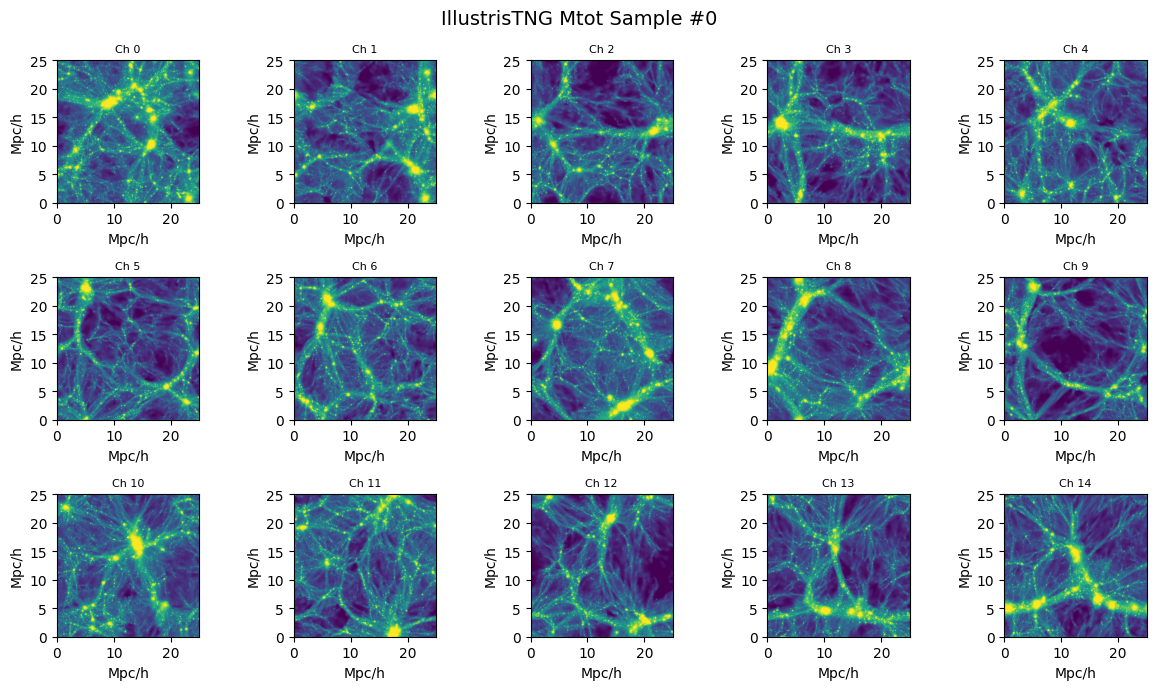

In [11]:
# SIMBA Mtot 샘플 시각화
show_sample_grid(maps_illustristng_mtot, sample_index=0, title="IllustrisTNG Mtot Sample #0")


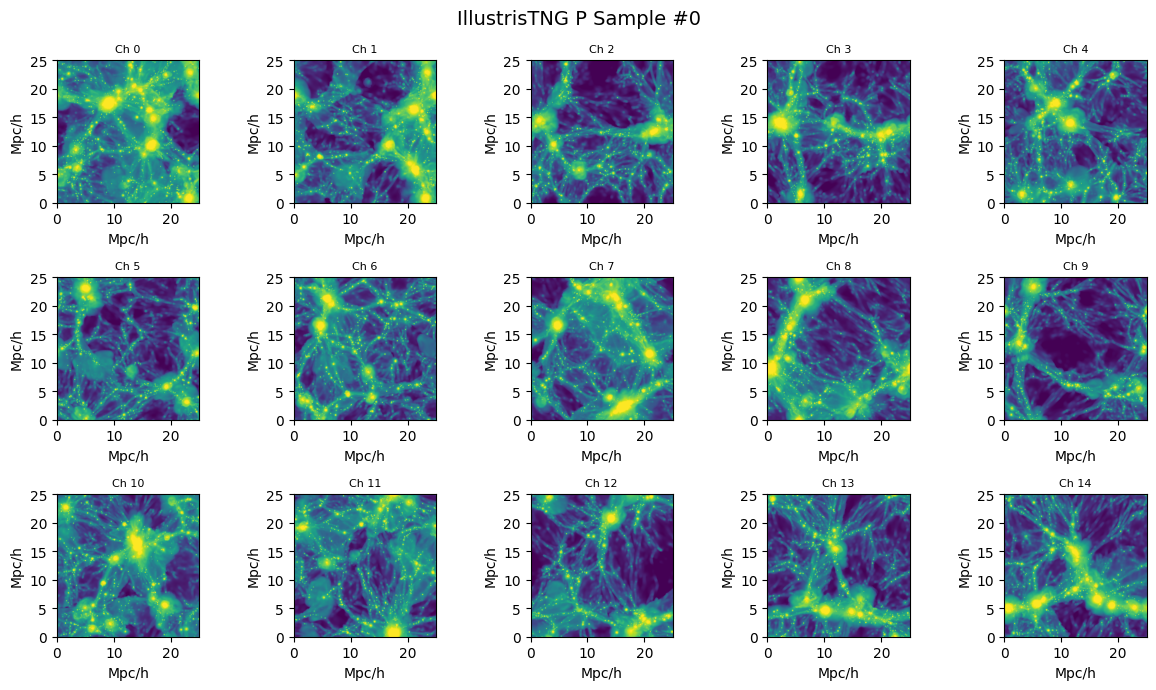

In [12]:

# SIMBA P 샘플 시각화
show_sample_grid(maps_illustristng_p, sample_index=0, title="IllustrisTNG P Sample #0")

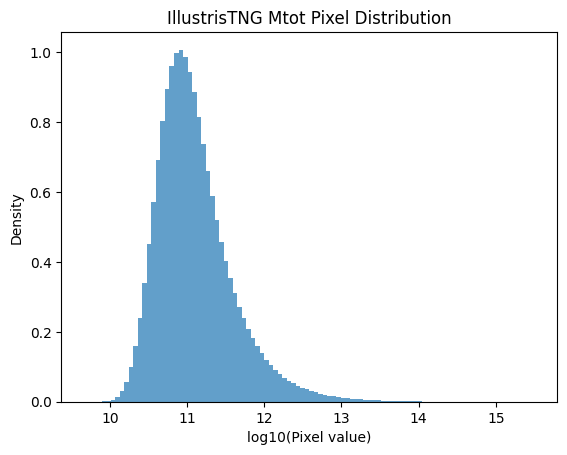

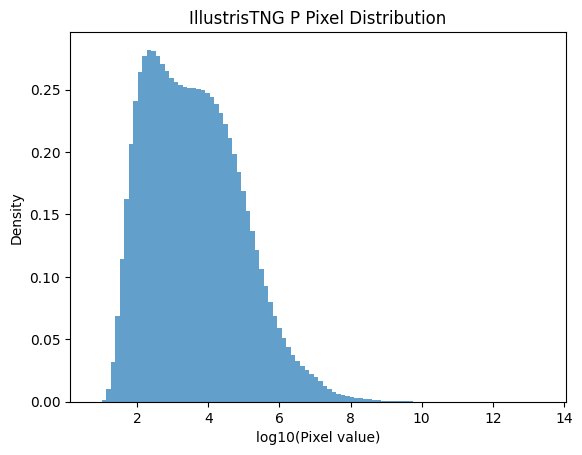

In [13]:
# 전체 분포 확인
plot_histograms(maps_illustristng_mtot, title="IllustrisTNG Mtot Pixel Distribution")
plot_histograms(maps_illustristng_p, title="IllustrisTNG P Pixel Distribution")


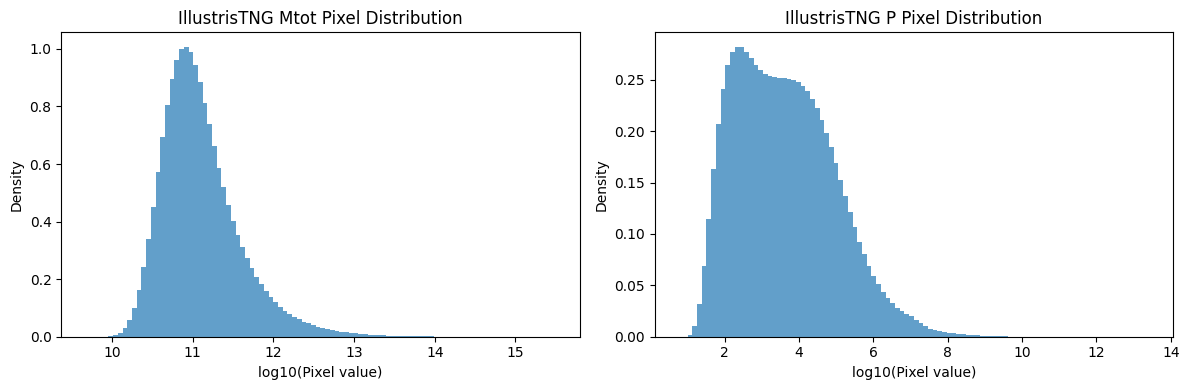

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_histograms_side_by_side(arr1, arr2, title1="", title2=""):
    """
    Plot two histograms side by side in one row.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1행 2열

    # 첫 번째 분포
    x1 = arr1.reshape(-1)
    x1 = x1[np.isfinite(x1) & (x1 > 0)]
    axes[0].hist(np.log10(x1), bins=100, density=True, alpha=0.7)
    axes[0].set_xlabel("log10(Pixel value)")
    axes[0].set_ylabel("Density")
    axes[0].set_title(title1)

    # 두 번째 분포
    x2 = arr2.reshape(-1)
    x2 = x2[np.isfinite(x2) & (x2 > 0)]
    axes[1].hist(np.log10(x2), bins=100, density=True, alpha=0.7)
    axes[1].set_xlabel("log10(Pixel value)")
    axes[1].set_ylabel("Density")
    axes[1].set_title(title2)

    plt.tight_layout()
    plt.show()


# 사용 예시
plot_histograms_side_by_side(
    maps_illustristng_mtot, maps_illustristng_p,
    title1="IllustrisTNG Mtot Pixel Distribution",
    title2="IllustrisTNG P Pixel Distribution"
)


In [15]:
# 입력: 2D 이미지 (shape: (N, 15, 256, 256))
# 출력: 스칼라 6개 (Ωm, σ8, SN1, AGN1, SN2, AGN2)